In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly[express] as plty
import math

ModuleNotFoundError: No module named 'plotly'

In [4]:
df = pd.read_csv("cybersecurity_attacks.csv")

In [5]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [8]:
df.shape

(40000, 25)

In [11]:
df.isna().sum()

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64

In [12]:
df.columns

Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'],
      dtype='object')

In [18]:
df.select_dtypes(exclude=[np.number]).columns.tolist()

['Timestamp',
 'Source IP Address',
 'Destination IP Address',
 'Protocol',
 'Packet Type',
 'Traffic Type',
 'Payload Data',
 'Malware Indicators',
 'Alerts/Warnings',
 'Attack Type',
 'Attack Signature',
 'Action Taken',
 'Severity Level',
 'User Information',
 'Device Information',
 'Network Segment',
 'Geo-location Data',
 'Proxy Information',
 'Firewall Logs',
 'IDS/IPS Alerts',
 'Log Source']

In [7]:
df.corr(numeric_only=True)

,Source Port,Destination Port,Packet Length,Anomaly Scores
Source Port,1.000000,-0.005216,0.003657,0.004826
Destination Port,-0.005216,1.000000,0.002581,-0.003616
Packet Length,0.003657,0.002581,1.000000,-0.003599
Anomaly Scores,0.004826,-0.003616,-0.003599,1.000000


In [56]:
cols_to_check = [
    "Attack Signature",
    "Severity Level",
    "Action Taken",
    "IDS/IPS Alerts",
    "Malware Indicators",
    "Alerts/Warnings",
    "Network Segment",
    "Firewall Logs",
    "Log Source"
]
for col in cols_to_check:
    print(f"\n--- {col} ---")
    print(df.groupby('Attack Type')[col].value_counts(dropna=False))


--- Attack Signature ---
Attack Type  Attack Signature
DDoS         Known Pattern B     6730
             Known Pattern A     6698
Intrusion    Known Pattern A     6717
             Known Pattern B     6548
Malware      Known Pattern A     6661
             Known Pattern B     6646
Name: count, dtype: int64

--- Severity Level ---
Attack Type  Severity Level
DDoS         High              4523
             Medium            4455
             Low               4450
Intrusion    Medium            4464
             High              4427
             Low               4374
Malware      Medium            4516
             High              4432
             Low               4359
Name: count, dtype: int64

--- Action Taken ---
Attack Type  Action Taken
DDoS         Blocked         4533
             Ignored         4459
             Logged          4436
Intrusion    Blocked         4553
             Ignored         4401
             Logged          4311
Malware      Logged          4448
  

In [11]:
# is it good news cause our model won't have bias for this colums cause it has pretty  fair distribution? or there is other meaning?
df.groupby('Attack Type')['Firewall Logs'].value_counts()

Attack Type  Firewall Logs
DDoS         Log Data         6712
Intrusion    Log Data         6623
Malware      Log Data         6704
Name: count, dtype: int64

In [12]:
df.groupby('Attack Type')['Firewall Logs'].value_counts(dropna=False)

Attack Type  Firewall Logs
DDoS         NaN              6716
             Log Data         6712
Intrusion    NaN              6642
             Log Data         6623
Malware      Log Data         6704
             NaN              6603
Name: count, dtype: int64

In [24]:
# is it good news cause our model won't have bias for this colums cause it has pretty  fair distribution? or there is other meaning?
df.groupby('Attack Type')['Alerts/Warnings'].value_counts()

Attack Type  Alerts/Warnings
DDoS         Alert Triggered    6673
Intrusion    Alert Triggered    6525
Malware      Alert Triggered    6735
Name: count, dtype: int64

In [13]:
df.groupby('Attack Type')['Alerts/Warnings'].value_counts(dropna=False)

Attack Type  Alerts/Warnings
DDoS         NaN                6755
             Alert Triggered    6673
Intrusion    NaN                6740
             Alert Triggered    6525
Malware      Alert Triggered    6735
             NaN                6572
Name: count, dtype: int64

In [53]:
# is it good news cause our model won't have bias for this colums cause it has pretty  fair distribution? or there is other meaning?
df.groupby('Attack Type')['Malware Indicators'].value_counts()

Attack Type  Malware Indicators
DDoS         IoC Detected          6654
Intrusion    IoC Detected          6665
Malware      IoC Detected          6681
Name: count, dtype: int64

In [15]:
df.groupby('Attack Type')['Malware Indicators'].value_counts(dropna=False)

Attack Type  Malware Indicators
DDoS         NaN                   6774
             IoC Detected          6654
Intrusion    IoC Detected          6665
             NaN                   6600
Malware      IoC Detected          6681
             NaN                   6626
Name: count, dtype: int64

In [10]:
df.groupby('Attack Type')['IDS/IPS Alerts'].value_counts()

Attack Type  IDS/IPS Alerts
DDoS         Alert Data        6697
Intrusion    Alert Data        6587
Malware      Alert Data        6666
Name: count, dtype: int64

In [16]:
df.groupby('Attack Type')['IDS/IPS Alerts'].value_counts(dropna=False)

Attack Type  IDS/IPS Alerts
DDoS         NaN               6731
             Alert Data        6697
Intrusion    NaN               6678
             Alert Data        6587
Malware      Alert Data        6666
             NaN               6641
Name: count, dtype: int64

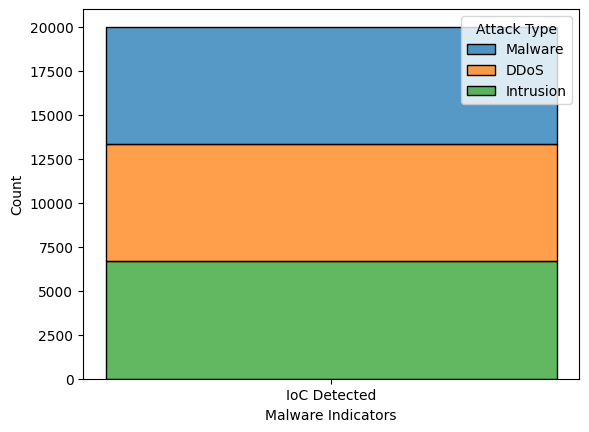

In [26]:
sns.histplot(x="Malware Indicators",hue="Attack Type",multiple="stack", data=df)
plt.show()

In [1]:
df.groupby('Attack Type')['Firewall Logs'].value_counts()

NameError: name 'df' is not defined

In [28]:
# entropy doesn't make any sense as the payload data seems like synthetic (need to check with Hanna).
from collections import Counter

def entropy_bytes(s):
    b = str(s).encode('utf-8', errors='ignore')
    if not b: return 0.0
    counts = Counter(b)
    total = len(b)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

df['Entropy'] = df['Payload Data'].apply(entropy_bytes)
df['Band'] = df['Entropy'].apply(lambda e: 'High' if e > 7 else ('Medium' if e >= 5 else 'Low'))
print(df['Band'].value_counts())

Band
Low    40000
Name: count, dtype: int64


In [8]:
df.groupby('Attack Type')['Packet Length'].describe()

,count,mean,std,min,25%,50%,75%,max
Attack Type,,,,,,,,
DDoS,13428.0,785.348749,416.685412,64.0,424.0,786.0,1150.0,1500.0
Intrusion,13265.0,780.924387,418.209936,64.0,412.0,785.0,1145.0,1500.0
Malware,13307.0,778.047945,413.221127,64.0,426.0,777.0,1135.0,1500.0


In [20]:
# doesn't show spike of Blocked if Severity Level is High
df.groupby(['Attack Type', 'Severity Level'])['Action Taken'].value_counts()

Attack Type  Severity Level  Action Taken
DDoS         High            Ignored         1549
                             Blocked         1508
                             Logged          1466
             Low             Blocked         1509
                             Ignored         1500
                             Logged          1441
             Medium          Logged          1529
                             Blocked         1516
                             Ignored         1410
Intrusion    High            Blocked         1523
                             Logged          1469
                             Ignored         1435
             Low             Blocked         1506
                             Ignored         1451
                             Logged          1417
             Medium          Blocked         1524
                             Ignored         1515
                             Logged          1425
Malware      High            Blocked         1499
        

In [21]:
# Doesn't show that IDS/IPS Alert trigger Alerts/Warnings
df.groupby('IDS/IPS Alerts')['Alerts/Warnings'].value_counts(dropna=False)

IDS/IPS Alerts  Alerts/Warnings
Alert Data      NaN                10037
                Alert Triggered     9913
Name: count, dtype: int64

In [26]:
# Doesn't show that certain signature is assigned to attack type
df.groupby('Attack Type')['Attack Signature'].value_counts(dropna=False)

Attack Type  Attack Signature
DDoS         Known Pattern B     6730
             Known Pattern A     6698
Intrusion    Known Pattern A     6717
             Known Pattern B     6548
Malware      Known Pattern A     6661
             Known Pattern B     6646
Name: count, dtype: int64

In [50]:
def split_ip(df, col):
    parts = df[col].str.split('.', expand=True).astype(float)
    parts.columns = [f"{col}_p1", f"{col}_p2", f"{col}_p3", f"{col}_p4"]
    return parts

df_split_ip = pd.concat([df, split_ip(df, "Source IP Address"), split_ip(df, "Destination IP Address"), split_ip(df, "Proxy Information")], axis=1)